# Notebook 2: Analyse en composantes principales et segmentation des pays

In [1]:
#importation des librairies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import os
os.environ["OMP_NUM_THREADS"] = "1"
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import fcluster

In [2]:
#importation du DF acp
acp= pd.read_csv('acp.csv', sep=',')
df_acp= pd.read_csv('df_acp.csv', sep=',')

In [3]:
#je rajoute les pays en index 
acp.index = df_acp.loc[acp.index, 'pays_FAO']

In [4]:
acp.head()

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,ind_perf_logistique,conso_energie,acces_electricite
pays_FAO,,,,,,,,
Afghanistan,1.53,50.88,49.12,525,-2.79,1.95,19.5,97.7
Afrique du Sud,35.69,24.27,78.71,6618,-0.28,3.38,7.9,84.4
Albanie,16.36,80.85,27.66,5006,0.37,2.66,36.9,99.9
Algérie,6.38,0.72,99.28,4555,-0.92,2.45,0.1,99.5
Allemagne,19.47,48.42,87.06,45554,0.57,4.20,15.2,100.0


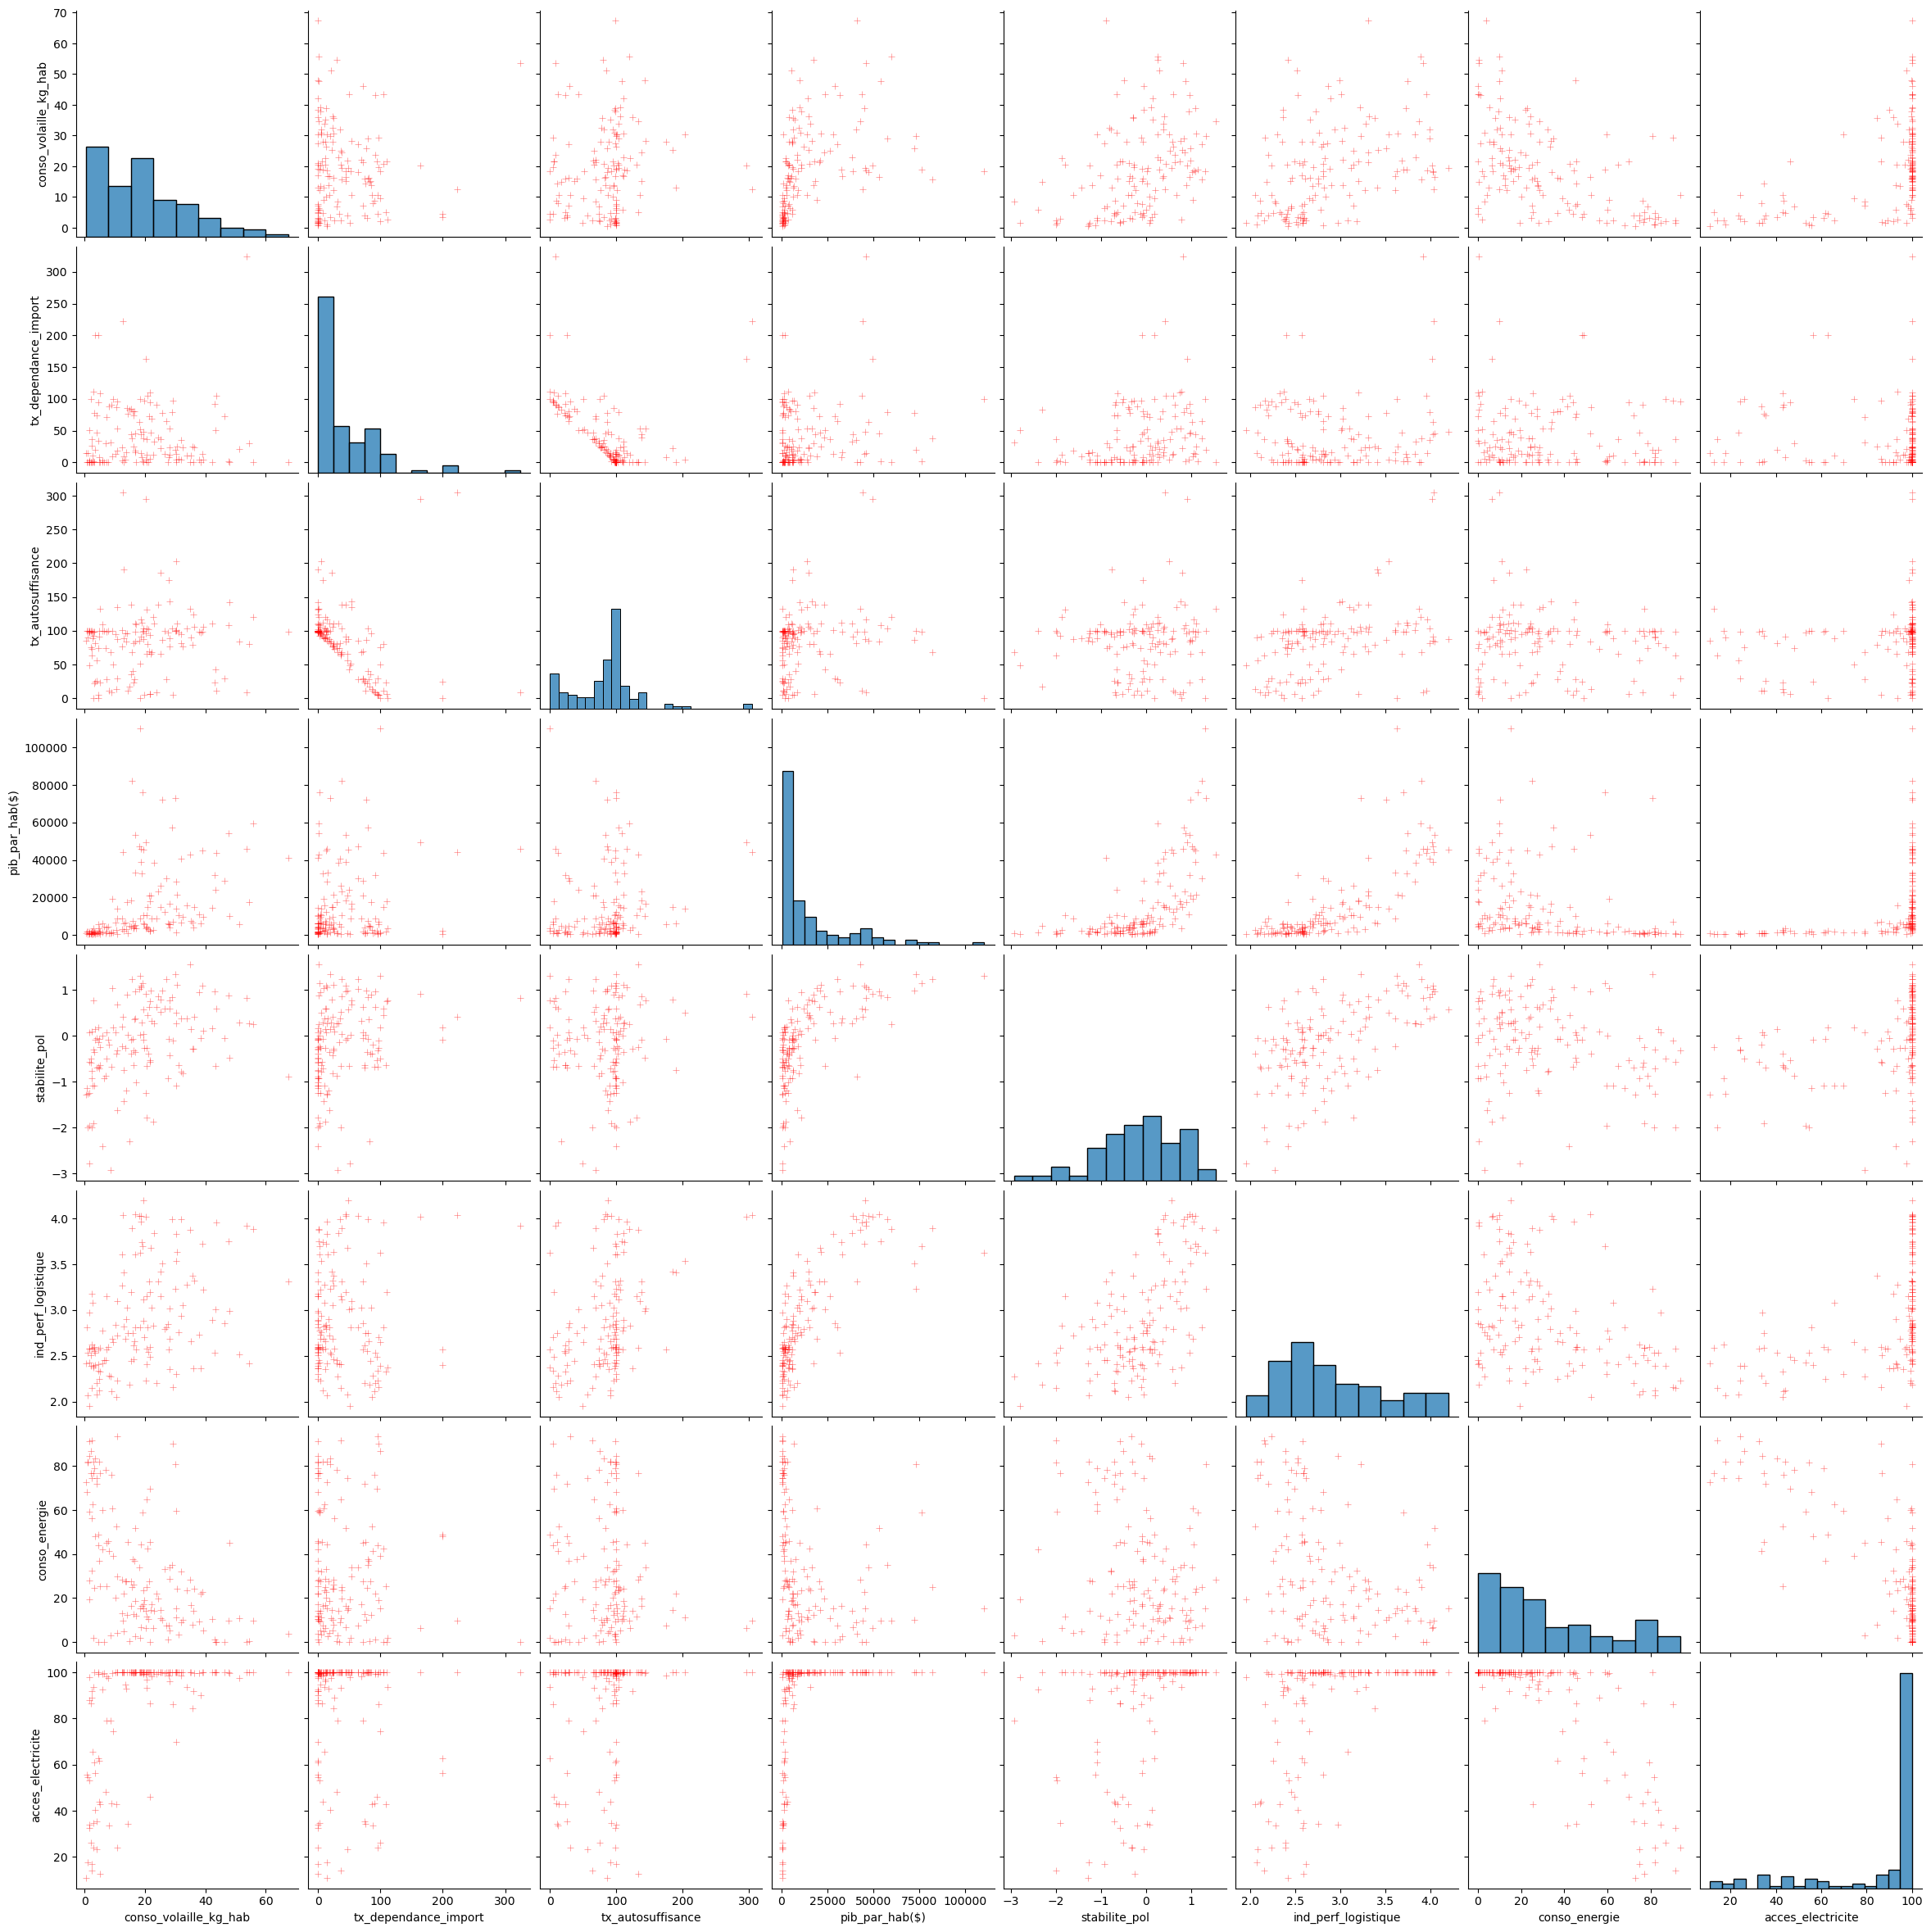

In [5]:
# Je compare les corrélations
data_pairs = sns.pairplot(acp, kind='scatter', height=3, diag_kind='auto',
                          markers="+", plot_kws= {'color': 'red','alpha': 0.5})
plt.show()

### Réalisation de l'ACP

#### étape 1: centrage et reduction des données

In [6]:
#je standardise pour mettre toutes les variables a la meme echelle 
scaler = StandardScaler()
acp_scaled = pd.DataFrame(
    scaler.fit_transform(acp),
    columns=acp.columns,
    index=acp.index
)

In [7]:
#verification
acp_scaled.describe().round(2)

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,ind_perf_logistique,conso_energie,acces_electricite
count,141.00,141.00,141.00,141.00,141.00,141.00,141.00,141.00
mean,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.32,-0.81,-1.75,-0.73,-3.11,-1.69,-1.20,-2.88
25%,-0.85,-0.75,-0.39,-0.66,-0.56,-0.78,-0.81,0.05
50%,-0.06,-0.35,0.17,-0.44,0.10,-0.25,-0.28,0.58
75%,0.63,0.64,0.33,0.18,0.73,0.66,0.58,0.58
max,3.42,5.66,4.58,4.78,1.91,2.31,2.27,0.58


Les variables sont centrées et réduites afin de conserver la structure statistique des données. (mean env= a 0 et std env -= a 1)

#### étape 2: analyse des corrélations entre les variables

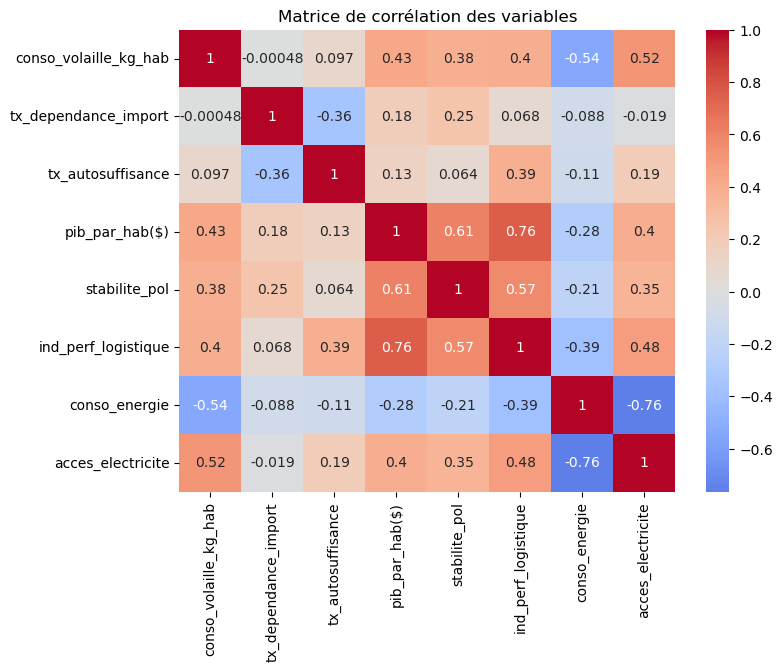

In [8]:
#analyse des corrélations avec une heatmap
plt.figure(figsize=(8,6))
sns.heatmap(acp_scaled.corr(), annot=True, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation des variables")
plt.savefig("matrice_correlation_variables.png", dpi=300, bbox_inches="tight")
plt.show()

Interprétations: 
-Les pays économiquement développés tendent à être plus stables politiquement, ce qui est un facteur clé pour une stratégie d’exportation à l’international.
-Un environnement politique stable favorise la consommation, notamment pour des produits alimentaires à plus forte valeur ajoutée comme la volaille de qualité.
-Les marchés à plus fort pouvoir d’achat présentent un potentiel de demande plus élevé pour les produits agroalimentaires.
-Les pays les plus autosuffisants sont mécaniquement moins dépendants des importations, ce qui traduit des structures de production locales plus développées.
-La capacité de production locale est relativement indépendante du niveau de développement économique, ce qui justifie l’analyse conjointe de ces dimensions dans une ACP.

#### étape 3: calcul des composantes principales

In [9]:
# transformer les valeurs initiales en axes factoriels
pca = PCA()
X_pca = pca.fit_transform(acp_scaled)

#### étape 4: l'éboulis des valeurs propres

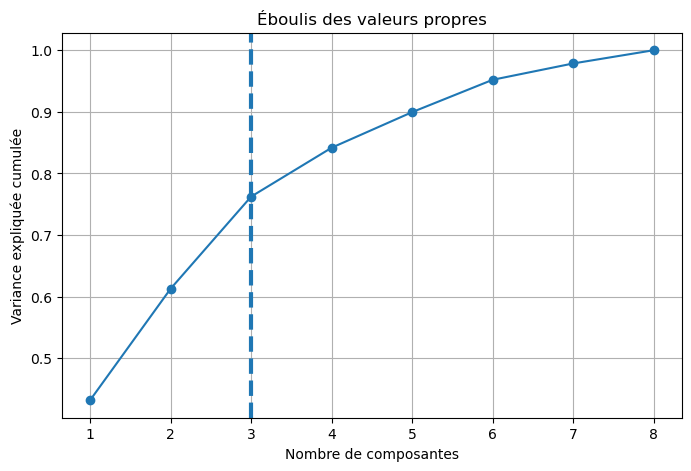

In [10]:
#visualisation éboulis des valeurs propres
n_components = range(1, len(pca.explained_variance_ratio_) + 1)
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(n_components, variance_cumulee, marker='o')
plt.axvline(x=3, linestyle='--', linewidth=3)
plt.xlabel("Nombre de composantes")
plt.ylabel("Variance expliquée cumulée")
plt.title("Éboulis des valeurs propres")
plt.grid(True)
plt.savefig("eboulis_des_valeurs_propres.png", dpi=300, bbox_inches="tight")
plt.show()

L’éboulis des valeurs propres met en évidence un coude au niveau de la deuxième composante. Les 3 premiers axes expliquent environ 76 % de la variance totale. Au-delà, le gain d’information devient plus léger. Deux dimensions ont donc été retenues afin de conserver un bon compromis entre réduction de dimension et interprétabilité des résultats.

#### étape 5: le cercle des corrélations

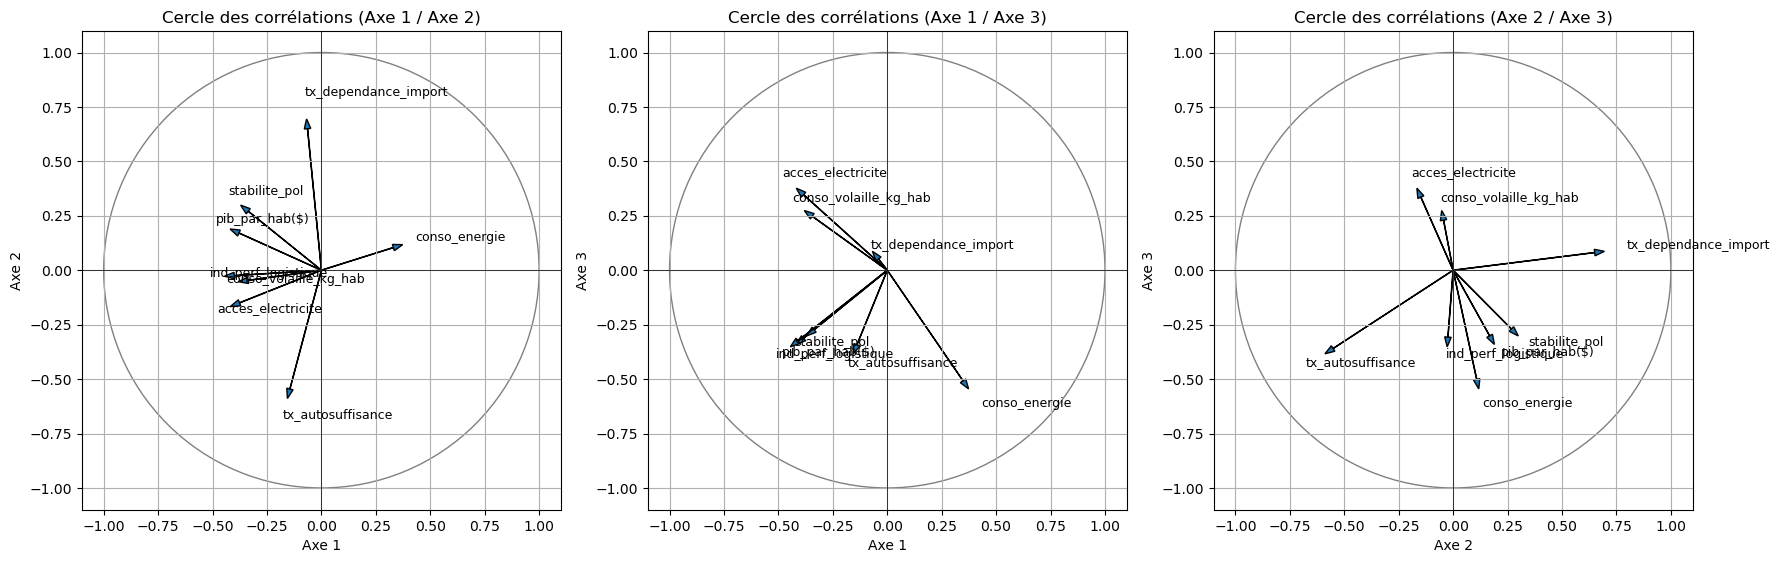

In [11]:
# Coordonnées des variables sur les 3 premiers axes
var_coords = pca.components_.T[:, :3]

axes_pairs = [
    (0, 1, "Axe 1", "Axe 2"),
    (0, 2, "Axe 1", "Axe 3"),
    (1, 2, "Axe 2", "Axe 3")
]

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

for ax, (i, j, label_x, label_y) in zip(axs, axes_pairs):

    # Cercle unité
    circle = plt.Circle((0, 0), 1, color='grey', fill=False)
    ax.add_artist(circle)

    # Flèches des variables
    for k, var in enumerate(acp.columns):
        ax.arrow(
            0, 0,
            var_coords[k, i],
            var_coords[k, j],
            head_width=0.03,
            length_includes_head=True
        )
        ax.text(
            var_coords[k, i] * 1.15,
            var_coords[k, j] * 1.15,
            var,
            fontsize=9
        )

    # Axes
    ax.axhline(0, color='black', linewidth=0.5)
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.set_aspect('equal', adjustable='box')

    ax.set_xlabel(label_x)
    ax.set_ylabel(label_y)
    ax.set_title(f"Cercle des corrélations ({label_x} / {label_y})")
    ax.grid(True)

plt.tight_layout()
plt.savefig("cercles_des_correlations.png", dpi=300, bbox_inches="tight")
plt.show()

#### étape 6: la projection des pays

In [12]:
#création du df de projection de pays
df_projection = pd.DataFrame(
    X_pca[:, :3],                 
    columns=['PC1', 'PC2', 'PC3'],
    index=acp.index               
)

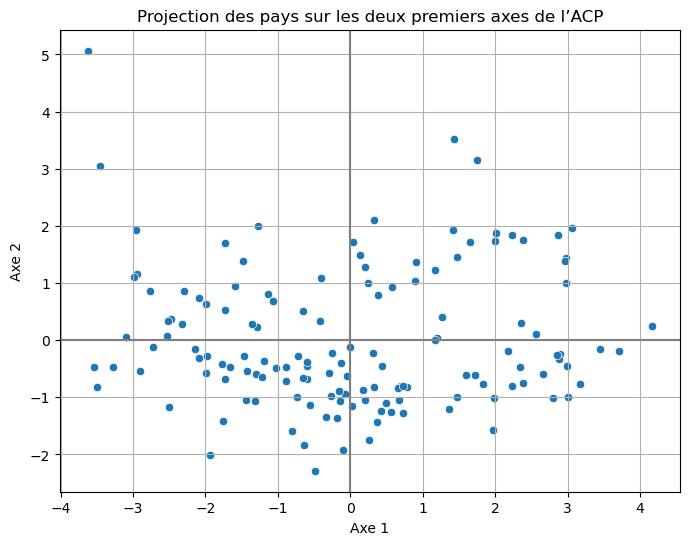

In [13]:
#representation visuelle en nuage de points de la projection des pays sur les 2 axes de l'ACP
plt.figure(figsize=(8,6))
sns.scatterplot(x="PC1", y="PC2", data=df_projection)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')

plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.title("Projection des pays sur les deux premiers axes de l’ACP")
plt.grid(True)
plt.show()

Certains pays présentent des profils atypiques, combinant un niveau de développement ou une structure de production très spécifique. Ils feront l’objet d’une analyse complémentaire lors de la segmentation.

#### étape 7: segmentation par classification ascendante hierarchique (CAH)

In [14]:
#préparation des données pour la CAH 
X_clust = df_projection[['PC1', 'PC2', 'PC3']]

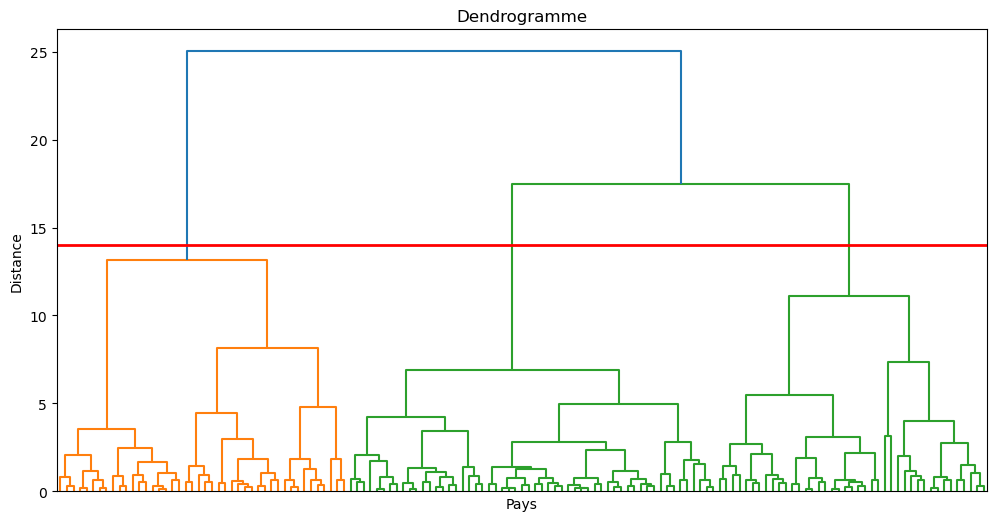

In [15]:
#construction et visualisation du dendrogramme
Z = linkage(X_clust, method='ward')
plt.figure(figsize=(12,6))
dendrogram(Z, no_labels=True)
plt.axhline(y=14, color='red', linewidth=2)
plt.title("Dendrogramme")
plt.xlabel("Pays")
plt.ylabel("Distance")
plt.savefig("dendrogramme.png", dpi=300, bbox_inches="tight")
plt.show()

In [16]:
#découpage de l'arbre en 3 clusters
clusters_cah = fcluster(Z, t=3, criterion='maxclust')
df_projection['cluster_cah'] = clusters_cah

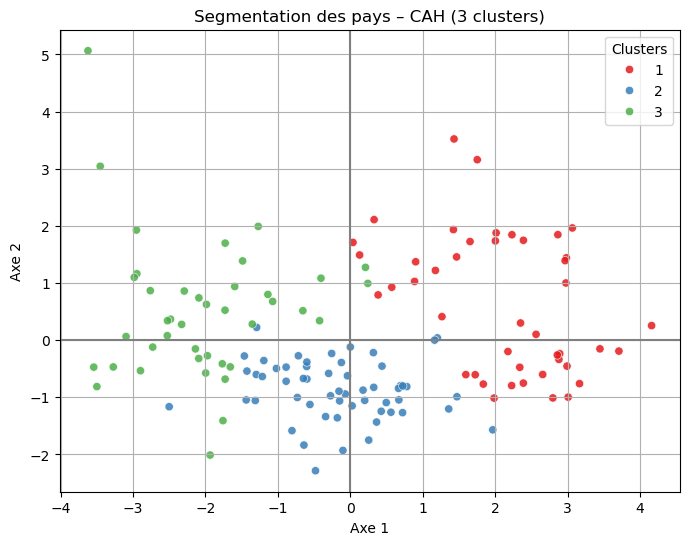

In [17]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df_projection, x='PC1', y='PC2', hue='cluster_cah', palette='Set1', alpha=0.85)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.xlabel("Axe 1")
plt.ylabel("Axe 2")
plt.title("Segmentation des pays – CAH (3 clusters)")
plt.grid(True)
plt.legend(title="Clusters")
plt.savefig("segmentation_cah.png", dpi=300, bbox_inches="tight")
plt.show()

La classification ascendante hiérarchique met en évidence trois groupes de pays distincts. 

#### étape 8: segmentation par k-means

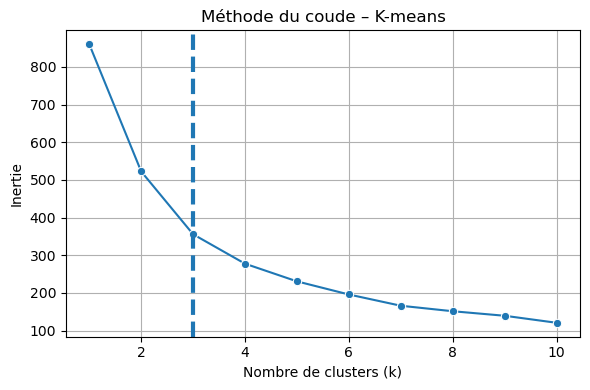

In [18]:
# Données pour le clustering (mêmes axes que ta projection)
X = df_projection[['PC1', 'PC2', 'PC3']].values   

inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(6,4))
sns.lineplot(x=list(K_range), y=inertias, marker='o')
plt.axvline(x=3, linestyle='--', linewidth=3)  
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertie")
plt.title("Méthode du coude – K-means")
plt.grid(True)
plt.tight_layout()
plt.savefig("methode_coude_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

La méthode du coude appliquée à l’algorithme K-means met en évidence un changement de pente autour de trois clusters. Ce choix permet de capturer l’essentiel de la structure des données tout en conservant une segmentation simple et interprétable.

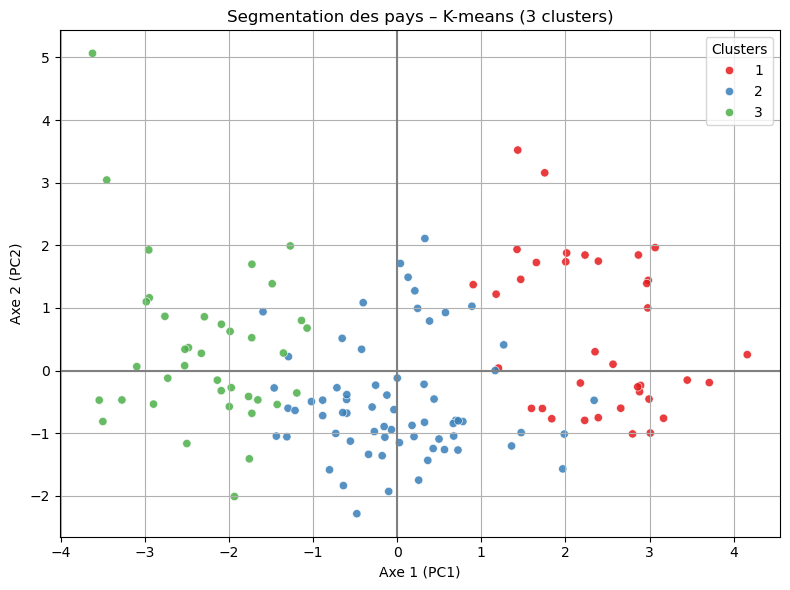

In [19]:
#projection seaborn de la vusualisation: segmentation des pays par k-means
k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

df_projection['cluster_km'] = kmeans.fit_predict(X) + 1  

mapping = {
    1: 2,  
    2: 1,  
    3: 3   
}

df_projection['cluster_km'] = df_projection['cluster_km'].map(mapping)
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=df_projection, x='PC1', y='PC2',
    hue='cluster_km', palette='Set1', alpha=0.85
)

plt.axhline(0, color='grey')
plt.axvline(0, color='grey')
plt.xlabel("Axe 1 (PC1)")
plt.ylabel("Axe 2 (PC2)")
plt.title("Segmentation des pays – K-means (3 clusters)")
plt.grid(True)
plt.legend(title="Clusters")
plt.tight_layout()
plt.savefig("segmentation_kmeans.png", dpi=300, bbox_inches="tight")
plt.show()

#### étape 8: visualisation des variables selon chacun des clusters

In [20]:
acp.head()

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,ind_perf_logistique,conso_energie,acces_electricite
pays_FAO,,,,,,,,
Afghanistan,1.53,50.88,49.12,525,-2.79,1.95,19.5,97.7
Afrique du Sud,35.69,24.27,78.71,6618,-0.28,3.38,7.9,84.4
Albanie,16.36,80.85,27.66,5006,0.37,2.66,36.9,99.9
Algérie,6.38,0.72,99.28,4555,-0.92,2.45,0.1,99.5
Allemagne,19.47,48.42,87.06,45554,0.57,4.20,15.2,100.0


In [21]:
# Exemple : on choisit le clustering K-means
acp_box = acp.copy()
acp_box['cluster'] = df_projection['cluster_km']   

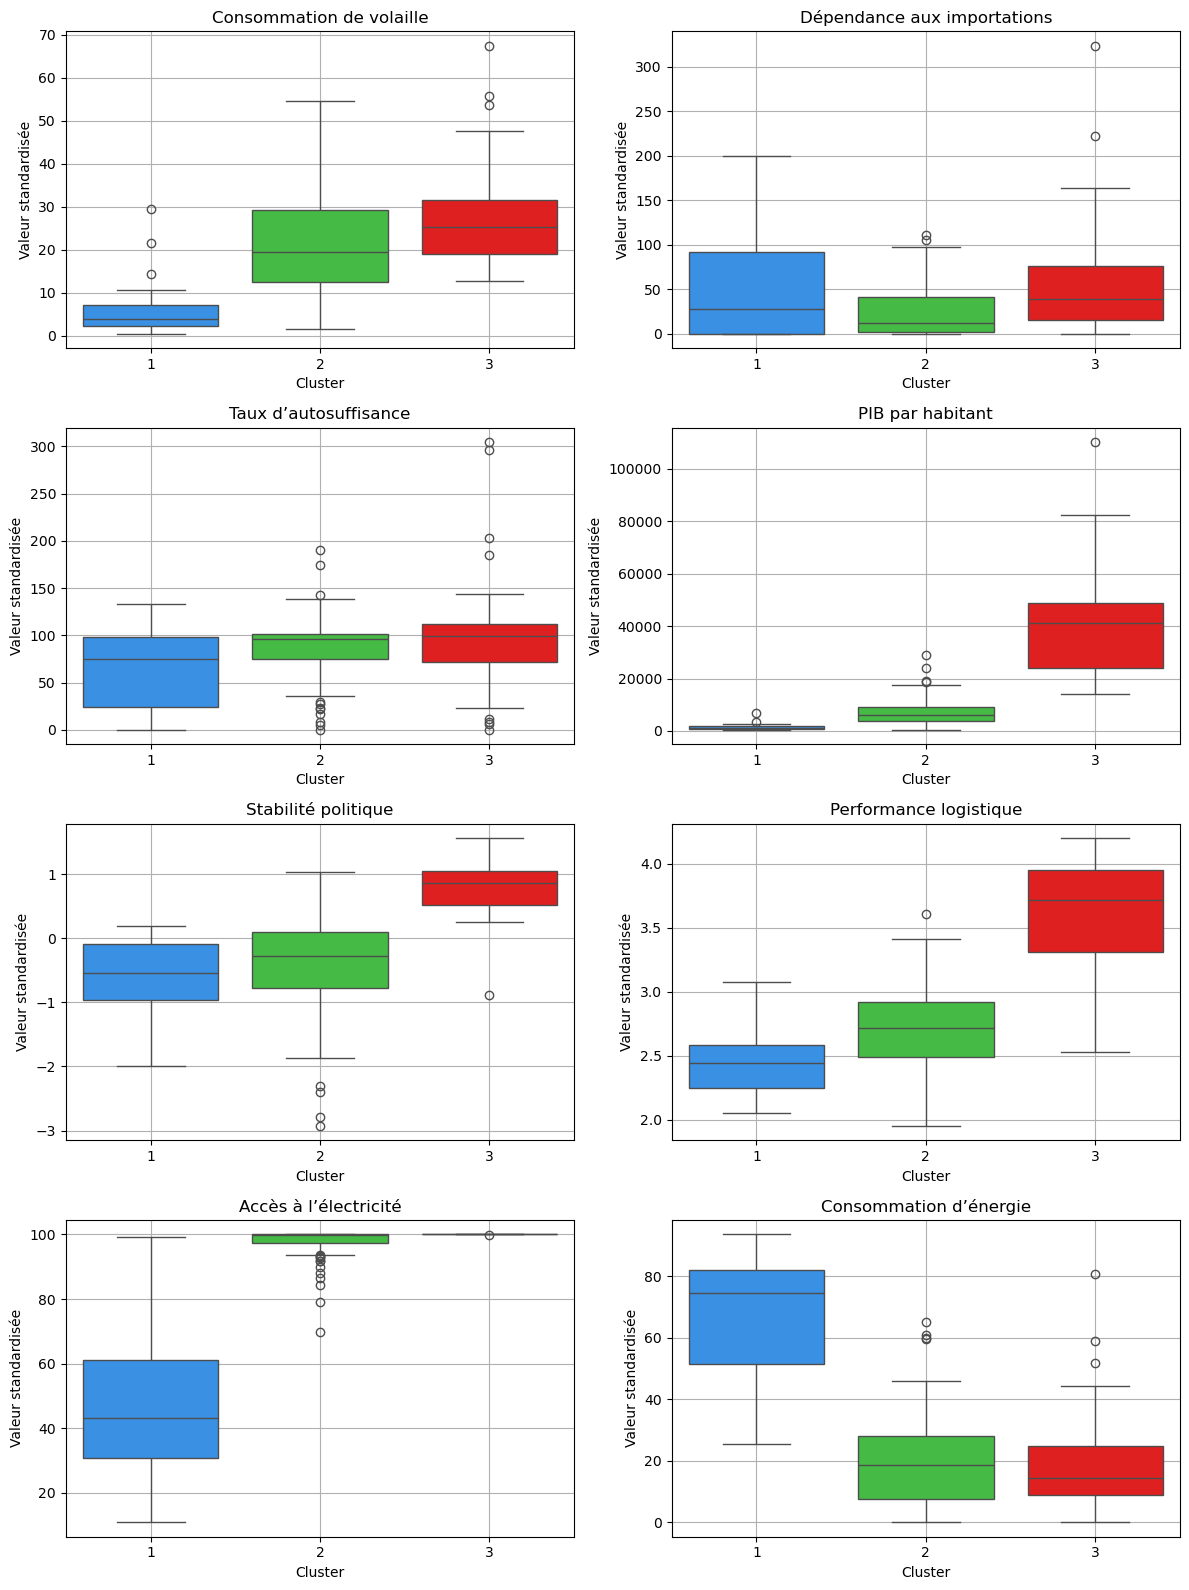

In [22]:
# affichage des 8 boxplots sur une meme image
download_dir = os.path.join(os.path.expanduser("~"), "Downloads")
variables = [
    'conso_volaille_kg_hab',
    'tx_dependance_import',
    'tx_autosuffisance',
    'pib_par_hab($)',
    'stabilite_pol',
    'ind_perf_logistique',
    'acces_electricite',
    'conso_energie'
]
titles = [
    "Consommation de volaille",
    "Dépendance aux importations",
    "Taux d’autosuffisance",
    "PIB par habitant",
    "Stabilité politique",
    "Performance logistique",
    "Accès à l’électricité",
    "Consommation d’énergie"
]
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,16))
axes = axes.flatten()
for i, var in enumerate(variables):
    sns.boxplot(
        x='cluster',
        y=var,
        hue='cluster',
        data=acp_box,
        palette=['dodgerblue', 'limegreen', 'red'],
        legend=False,
        ax=axes[i]
    )
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel("Valeur standardisée")
    axes[i].grid(True)
plt.tight_layout()
filename = os.path.join(download_dir, "boxplots_clusters_global.png")
plt.savefig(filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

La segmentation est très proche de la segementation des pays faite avec la CAH 

In [23]:
# comparaison CAH contre K_means 
pd.crosstab(
    df_projection['cluster_cah'],
    df_projection['cluster_km']
)

cluster_km,1,2,3
cluster_cah,,,
1,35,9,0
2,1,52,3
3,0,6,35


L’association entre les clusters issus de la CAH et ceux du K-means a été réalisée en s’appuyant sur la correspondance majoritaire des individus. Deux clusters présentent une correspondance quasi parfaite, tandis qu’un troisième montre une frontière plus diffuse, ce qui est fréquent dans les méthodes de clustering non supervisées.

cluster_cah 1 correspond a 98% des cluster_kmeans 1 

cluster_cah 2 correspond a  100% des cluster_kmeans 0

cluster_cah 3 correspond a 68% des cluster_kmeans 2

In [24]:
acp.head()

,conso_volaille_kg_hab,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,ind_perf_logistique,conso_energie,acces_electricite
pays_FAO,,,,,,,,
Afghanistan,1.53,50.88,49.12,525,-2.79,1.95,19.5,97.7
Afrique du Sud,35.69,24.27,78.71,6618,-0.28,3.38,7.9,84.4
Albanie,16.36,80.85,27.66,5006,0.37,2.66,36.9,99.9
Algérie,6.38,0.72,99.28,4555,-0.92,2.45,0.1,99.5
Allemagne,19.47,48.42,87.06,45554,0.57,4.20,15.2,100.0


In [25]:
df_acp.head()

,pays_code,pays_FAO,conso_volaille_kg_hab,Disponibilité intérieure,Importations - Quantité,Production,tx_dependance_import,tx_autosuffisance,pib_par_hab($),stabilite_pol,nb_hab,ind_perf_logistique,conso_energie,acces_electricite
0,AFG,Afghanistan,1.53,57.0,29.0,28.0,50.88,49.12,525.0,-2.79,36296113,1.95,19.5,97.7
1,ZAF,Afrique du Sud,35.69,2118.0,514.0,1667.0,24.27,78.71,6618.0,-0.28,57009756,3.38,7.9,84.4
2,ALB,Albanie,16.36,47.0,38.0,13.0,80.85,27.66,5006.0,0.37,2884169,2.66,36.9,99.9
3,DZA,Algérie,6.38,277.0,2.0,275.0,0.72,99.28,4555.0,-0.92,41389189,2.45,0.1,99.5
4,DEU,Allemagne,19.47,1739.0,842.0,1514.0,48.42,87.06,45554.0,0.57,82658409,4.20,15.2,100.0


In [26]:
# mise de pays_FAO en index de df_acp pour utiliser join
df_acp = df_acp.set_index('pays_FAO')

In [27]:
#jointure avec les données brutes
df_final = df_acp.join(
    df_projection,
    how='inner'
)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 141 entries, Afghanistan to Slovénie
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   pays_code                 141 non-null    object 
 1   conso_volaille_kg_hab     141 non-null    float64
 2   Disponibilité intérieure  139 non-null    float64
 3   Importations - Quantité   139 non-null    float64
 4   Production                137 non-null    float64
 5   tx_dependance_import      139 non-null    float64
 6   tx_autosuffisance         137 non-null    float64
 7   pib_par_hab($)            140 non-null    float64
 8   stabilite_pol             139 non-null    float64
 9   nb_hab                    141 non-null    int64  
 10  ind_perf_logistique       119 non-null    float64
 11  conso_energie             141 non-null    float64
 12  acces_electricite         141 non-null    float64
 13  PC1                       141 non-null    float64
 14  

In [28]:
# 1) Créer cluster_final à partir de cluster_kmeans
mapping = {
0: 2, # pays autosuffisants
1: 1, # pays en développement
2: 3 # pays développés
}
df_final['cluster_final'] = df_final['cluster_km'].map(mapping)

labels = {
1: "Pays en développement",
2: "Pays autosuffisants",
3: "Pays développés"
}

df_final['segment'] = df_final['cluster_final'].map(labels)

In [29]:
base = (
df_final[df_final['cluster_final'] == 3]
.dropna(subset=['pib_par_hab($)', 'stabilite_pol', 'ind_perf_logistique'])
.copy()
)

shortlist = (
base.loc[
(base['pib_par_hab($)'] >= 30000) &
(base['stabilite_pol'] >= 0) &
(base['ind_perf_logistique'] >= 3)
]
.sort_values(by='PC1', ascending=False)
.head(5)
)

shortlist[['PC1','PC2','pib_par_hab($)','stabilite_pol','ind_perf_logistique','segment']]

,PC1,PC2,pib_par_hab($),stabilite_pol,ind_perf_logistique,segment
pays_FAO,,,,,,
Pays-Bas (Royaume des),0.724979,-0.800815,49514.0,0.91,4.02,Pays développés
France,0.573172,0.926976,38687.0,0.27,3.84,Pays développés
Nouvelle-Zélande,0.438064,-0.453798,42950.0,1.56,3.88,Pays développés
République de Corée,0.363298,-1.432587,33297.0,0.38,3.61,Pays développés
Luxembourg,0.242365,0.993713,110193.0,1.31,3.63,Pays développés
